In [1]:
# Import libraries
import numpy as np
import tensorflow as tf
from tensorflow.keras import Sequential, models, layers, Input
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.losses import SparseCategoricalCrossentropy
import matplotlib.pyplot as plt

In [2]:
# Config constants
IMAGE_SIZE = 256
BATCH_SIZE = 32
CHANNELS = 3
EPOCHS = 10
INPUT_SHAPE = (IMAGE_SIZE, IMAGE_SIZE, CHANNELS)

In [3]:
# Load images
dataset = image_dataset_from_directory(
    "tomato_data",
    shuffle=True,
    batch_size=BATCH_SIZE,
    image_size=(IMAGE_SIZE, IMAGE_SIZE),
    verbose=True
)
class_names = dataset.class_names
class_names

Found 16011 files belonging to 10 classes.


['Tomato_Bacterial_spot',
 'Tomato_Early_blight',
 'Tomato_Late_blight',
 'Tomato_Leaf_Mold',
 'Tomato_Septoria_leaf_spot',
 'Tomato_Spider_mites_Two_spotted_spider_mite',
 'Tomato__Target_Spot',
 'Tomato__Tomato_YellowLeaf__Curl_Virus',
 'Tomato__Tomato_mosaic_virus',
 'Tomato_healthy']

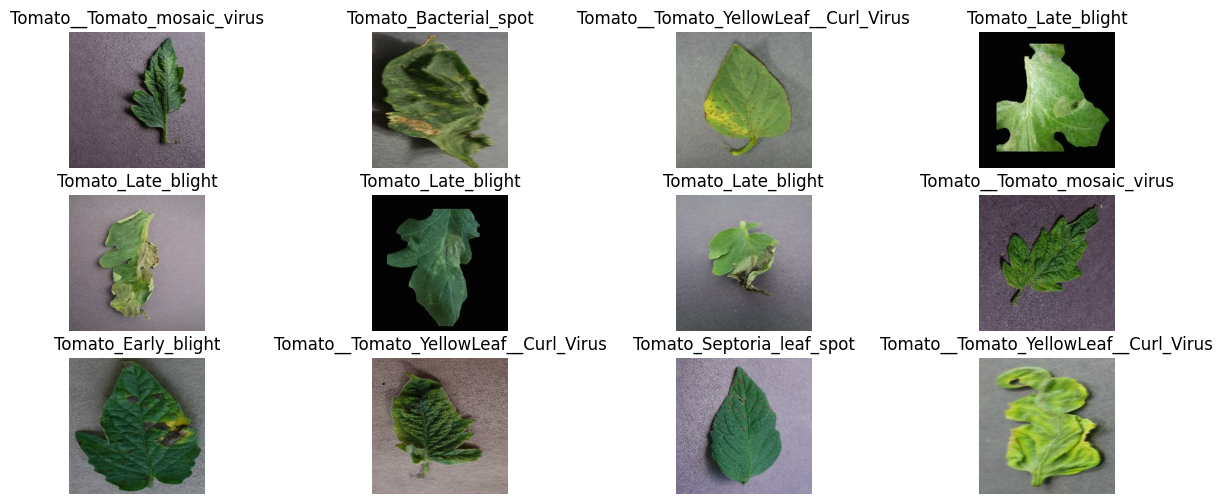

In [4]:
# Check data
plt.figure(figsize=(15, 6))
for image_batch, label_batch in dataset:
    for i in range(12):
        plt.subplot(3, 4, i+1)
        plt.imshow(image_batch[i].numpy().astype('int'))
        plt.title(class_names[label_batch[i]])
        plt.axis('off')
        
    plt.show()
    break

In [5]:
# devide dataset into train, test, validate
len(dataset) * 0.7, len(dataset) * 0.2, len(dataset) * 0.1
train_dataset = dataset.take(350)
new_dataset = dataset.skip(350)
validation_dataset = new_dataset.take(100)
test_dataset = new_dataset.skip(50)
print(len(train_dataset), len(validation_dataset), len(test_dataset))

350 100 101


In [6]:
# cache dataset
train_dataset = train_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
validation_dataset = validation_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)
test_dataset = test_dataset.cache().shuffle(1000).prefetch(buffer_size=tf.data.AUTOTUNE)

In [7]:
# Create model
model = Sequential([
    # input layer
    Input(shape=INPUT_SHAPE),

    # reshape and rotation
    layers.Resizing(IMAGE_SIZE, IMAGE_SIZE),
    layers.Rescaling(1.0/255),

    # Data Augmentation
    layers.RandomFlip('horizontal_and_vertical'),
    layers.RandomRotation(0.2),

    # first hidden layer
    layers.Conv2D(32, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # second hidden layer
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # third hidden layer
    layers.Conv2D(64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    
    # fourth hidden layer
    layers.Conv2D(128, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),

    # flatten layer
    layers.Flatten(),
    
    # Dense layer
    layers.Dense(64, activation='relu'),

    # Output layer
    layers.Dense(len(class_names), activation='softmax')
])

In [8]:
# get model summary
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ resizing (Resizing)                  │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ rescaling (Rescaling)                │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_flip (RandomFlip)             │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ random_rotation (RandomRotation)     │ (None, 256, 256, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d (Conv2D)                      │ (None, 254, 254, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,736,522 (6.62 MB)

 Trainable params: 1,736,522 (6.62 MB)

 Non-trainable params: 0 (0.00 B)

In [9]:
# compile model
model.compile(
    optimizer='adam',
    loss=SparseCategoricalCrossentropy(from_logits=False),
    metrics=['accuracy']
)

In [10]:
# train model
model_history = model.fit(
    train_dataset,
    epochs=EPOCHS,
    batch_size=BATCH_SIZE,
    validation_data=validation_dataset,
    verbose=1
)

Epoch 1/2
350/350 ━━━━━━━━━━━━━━━━━━━━ 630s 2s/step - accuracy: 0.5290 - loss: 1.3387 - val_accuracy: 0.6500 - val_loss: 1.1725
Epoch 2/2
350/350 ━━━━━━━━━━━━━━━━━━━━ 537s 2s/step - accuracy: 0.7547 - loss: 0.7091 - val_accuracy: 0.8097 - val_loss: 0.5143


In [13]:
model_history.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

<Figure size 1000x600 with 0 Axes>

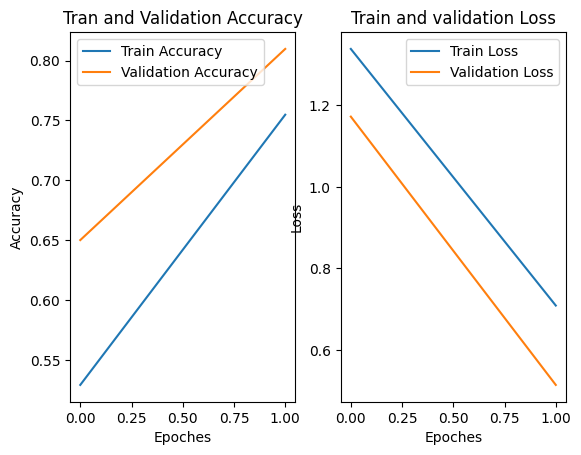

In [25]:
# plot accuracy and loss
plt.figure(figsize=(10, 6))
fig, ax = plt.subplots(1, 2)
ax[0].plot(model_history.history['accuracy'], label='Train Accuracy')
ax[0].plot(model_history.history['val_accuracy'], label='Validation Accuracy')
ax[0].set_xlabel('Epoches')
ax[0].set_ylabel('Accuracy')
ax[0].set_title('Tran and Validation Accuracy')
ax[0].legend()

ax[1].plot(model_history.history['loss'], label='Train Loss')
ax[1].plot(model_history.history['val_loss'], label='Validation Loss')
ax[1].set_xlabel('Epoches')
ax[1].set_ylabel('Loss')
ax[1].set_title('Train and validation Loss')
ax[1].legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 321ms/step
Actual: Tomato_Leaf_Mold
Predicted: Tomato_Leaf_Mold


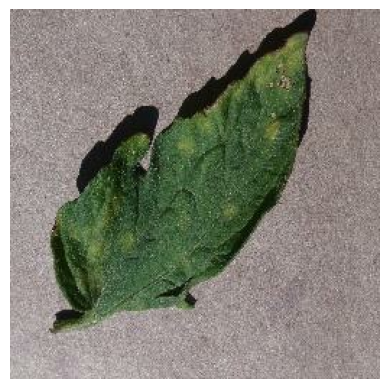

In [32]:
# predict new image
for image_batch, label_batch in test_dataset:
    predictions = model.predict(image_batch)
    print("Actual:", class_names[label_batch[0]])
    print("Predicted:", class_names[np.argmax(predictions[0])])
    plt.imshow(image_batch[0].numpy().astype('int'))
    plt.axis('off')
    break

In [34]:
# save model
model.save('tomato_disease1.keras')